In [1711]:
%pip install pandas
%pip install matplotlib
%pip install mlxtend
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [1712]:
df1 = pd.read_csv('train.csv')
df1

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [1713]:
df1.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
151,152,1,1,"Pears, Mrs. Thomas (Edith Wearne)",female,22.0,1,0,113776,66.6000,C2,S
572,573,1,1,"Flynn, Mr. John Irwin (""Irving"")",male,36.0,0,0,PC 17474,26.3875,E25,S
87,88,0,3,"Slocovski, Mr. Selman Francis",male,NaN,0,0,SOTON/OQ 392086,8.0500,NaN,S
545,546,0,1,"Nicholson, Mr. Arthur Ernest",male,64.0,0,0,693,26.0000,NaN,S


In [1714]:

#fancy indexing
df1['Sex'] = df1['Sex'].map({
    'male' : 1,
    'female' : 0,
})

df1.drop(['PassengerId','Name','Ticket','Cabin'], axis=1, inplace=True)

df1.sample(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
773,0,3,1,NaN,0,0,7.2250,C
309,1,1,0,30.0,0,0,56.9292,C
629,0,3,1,NaN,0,0,7.7333,Q
339,0,1,1,45.0,0,0,35.5000,S


In [1715]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    str    
dtypes: float64(2), int64(5), str(1)
memory usage: 55.8 KB


In [1716]:
df1['Embarked'] = df1['Embarked'].str.strip()
df1['Embarked'] = df1['Embarked'].map({
    'S' : 0,
    'C' : 1,
    'Q' : 2,              
})
df1.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
822,0,1,1,38.0,0,0,0.00,0.0
343,0,2,1,25.0,0,0,13.00,0.0
655,0,2,1,24.0,2,0,73.50,0.0
280,0,3,1,65.0,0,0,7.75,2.0
526,1,2,0,50.0,0,0,10.50,0.0


<Axes: >

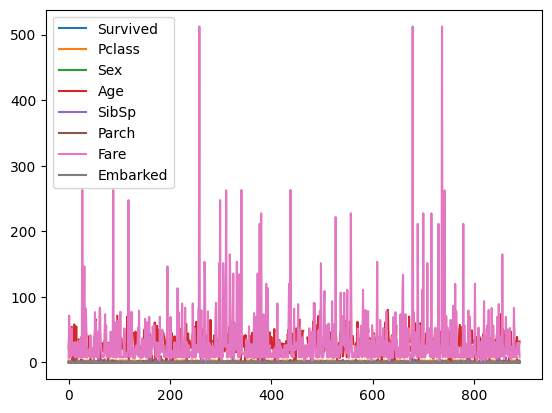

In [1717]:
df1.plot()

In [1718]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    float64
dtypes: float64(3), int64(5)
memory usage: 55.8 KB


In [1719]:
# brute force lol df1.dropna(inplace=True)
#checking each column now to improve accuracy :(
    
from numpy import median
from math import ceil

df1['Age'] = df1['Age'].fillna(df1['Age'].mean())#mean is giving more accuracy than median 
df1['Embarked'] = df1['Embarked'].fillna(df1['Embarked'].mode()[0])

#ony age and embarked has missing lol


In [1720]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    float64
dtypes: float64(3), int64(5)
memory usage: 55.8 KB


In [1721]:
df1.shape[0]

891

In [1722]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    float64
dtypes: float64(3), int64(5)
memory usage: 55.8 KB


In [1723]:
titanic_train_input = df1.iloc[:,1:]
titanic_train_output = df1.iloc[:,0]
titanic_train_input.sample(5)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
13,3,1,39.0,1,5,31.2750,0.0
685,2,1,25.0,1,2,41.5792,1.0
845,3,1,42.0,0,0,7.5500,0.0
785,3,1,25.0,0,0,7.2500,0.0
243,3,1,22.0,0,0,7.1250,0.0


In [1724]:
titanic_train_output.sample(5)

341    1
413    0
89     0
503    0
370    1
Name: Survived, dtype: int64

In [1725]:
%pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [1726]:
import sklearn
from sklearn.model_selection import train_test_split

In [1727]:
#x is input / inputs
#y is output 

x_train,x_test,y_train,y_test= train_test_split(titanic_train_input,titanic_train_output,test_size=0.15,random_state=42)

In [1728]:
x_train.shape

(757, 7)

In [1729]:
x_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
709,3,1,29.699118,1,1,15.2458,1.0
439,2,1,31.000000,0,0,10.5000,0.0
840,3,1,20.000000,0,0,7.9250,0.0
720,2,0,6.000000,0,1,33.0000,0.0
39,3,0,14.000000,1,0,11.2417,1.0
...,...,...,...,...,...,...,...
494,3,1,21.000000,0,0,8.0500,0.0
359,3,0,29.699118,0,0,7.8792,2.0
65,3,1,29.699118,1,1,15.2458,1.0
481,2,1,29.699118,0,0,0.0000,0.0


In [1730]:
y_train.shape

(757,)

In [1731]:
y_test

709    1
439    0
840    0
720    1
39     1
      ..
494    0
359    1
65     1
481    0
777    1
Name: Survived, Length: 134, dtype: int64

In [1732]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_train

array([[-1.61946989,  0.72964969,  1.5035061 , ..., -0.46885892,
         0.48626357,  1.02600288],
       [ 0.81294818, -1.3705207 , -1.12874522, ..., -0.46885892,
        -0.3485533 ,  1.02600288],
       [-1.61946989, -1.3705207 ,  0.00924807, ..., -0.46885892,
         1.54669424,  1.02600288],
       ...,
       [ 0.81294818,  0.72964969,  0.88415285, ..., -0.46885892,
        -0.35535173, -0.55583863],
       [-1.61946989, -1.3705207 , -1.20616438, ...,  1.99590636,
         1.7258767 , -0.55583863],
       [-1.61946989,  0.72964969, -0.66423028, ...,  0.76352372,
         0.88639193, -0.55583863]], shape=(757, 7))

In [1733]:
x_test = scaler.transform(x_test)
x_test

array([[ 8.12948177e-01,  7.29649686e-01,  9.24806686e-03,
         4.00771682e-01,  7.63523720e-01, -3.32994949e-01,
         1.02600288e+00],
       [-4.03260855e-01,  7.29649686e-01,  1.09961281e-01,
        -4.71021890e-01, -4.68858916e-01, -4.26270380e-01,
        -5.55838627e-01],
       [ 8.12948177e-01,  7.29649686e-01, -7.41649439e-01,
        -4.71021890e-01, -4.68858916e-01, -4.76880231e-01,
        -5.55838627e-01],
       [-4.03260855e-01, -1.37052070e+00, -1.82551763e+00,
        -4.71021890e-01,  7.63523720e-01,  1.59516233e-02,
        -5.55838627e-01],
       [ 8.12948177e-01, -1.37052070e+00, -1.20616438e+00,
         4.00771682e-01, -4.68858916e-01, -4.11692777e-01,
         1.02600288e+00],
       [-1.61946989e+00, -1.37052070e+00, -2.77134501e-01,
        -4.71021890e-01, -4.68858916e-01,  9.17101794e-01,
        -5.55838627e-01],
       [ 8.12948177e-01, -1.37052070e+00,  9.24806686e-03,
        -4.71021890e-01, -4.68858916e-01, -4.80319735e-01,
         2.6078443

In [1734]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [1735]:
y_pred = clf.predict(x_test)

In [1736]:
y_pred.shape

(134,)

In [1737]:
y_test.shape

(134,)

In [1738]:
from sklearn.metrics import precision_score,accuracy_score

In [1739]:
accuracy_score(y_test,y_pred)

0.8059701492537313

In [1740]:
precision_score(y_test,y_pred)

0.7884615384615384

In [1741]:
df2 = pd.read_csv('test.csv')
df2.sample(5)
passenger_ids = df2['PassengerId']

In [1742]:
df2.drop(['PassengerId','Name','Ticket','Cabin'],axis=1,inplace=True)
df2.sample(5)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
257,3,male,28.0,0,0,8.0500,S
29,3,male,NaN,2,0,21.6792,C
372,1,male,49.0,0,0,0.0000,S
335,1,male,30.0,0,0,26.0000,S
188,3,female,NaN,8,2,69.5500,S


In [1743]:
df2['Sex'] = df2['Sex'].map({
    'male' : 1,
    'female' : 0,
})
df1.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
195,1,1,0,58.0,0,0,146.5208,1.0
217,0,2,1,42.0,1,0,27.0000,0.0
720,1,2,0,6.0,0,1,33.0000,0.0
395,0,3,1,22.0,0,0,7.7958,0.0
446,1,2,0,13.0,0,1,19.5000,0.0


In [1744]:

df2['Embarked'] = df2['Embarked'].str.strip()

df2['Embarked'] = df2['Embarked'].map({
    'S':0,
    'C':1,
    'Q':2
})

<Axes: >

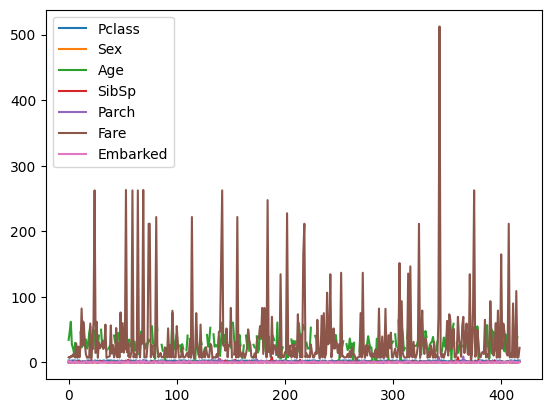

In [1745]:
df2.plot()

In [1746]:
titanic_test = df2

In [1747]:
titanic_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Sex       418 non-null    int64  
 2   Age       332 non-null    float64
 3   SibSp     418 non-null    int64  
 4   Parch     418 non-null    int64  
 5   Fare      417 non-null    float64
 6   Embarked  418 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 23.0 KB


In [1748]:
titanic_test['Age'] = titanic_test['Age'].fillna(df1['Age'].mean())
titanic_test['Fare'] = titanic_test['Fare'].fillna(df1['Fare'].mean())
titanic_test['Embarked'] = titanic_test['Embarked'].fillna(df1['Embarked'].mode()[0])


In [1749]:
titanic_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Sex       418 non-null    int64  
 2   Age       418 non-null    float64
 3   SibSp     418 non-null    int64  
 4   Parch     418 non-null    int64  
 5   Fare      418 non-null    float64
 6   Embarked  418 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 23.0 KB


In [1750]:
titanic_test = scaler.transform(titanic_test)

In [1751]:
predictions = clf.predict(titanic_test)

predictions.shape[0]

418

In [1752]:
submission = pd.DataFrame({
    'PassengerId' : passenger_ids,
    'Survived' : predictions
    
})

submission.to_csv("prediction.csv",index=False)